In [1]:
import numpy as np
import kingmaker
from timeit import timeit

from matplotlib import pyplot as plt
from matplotlib import scale
from matplotlib.colors import LogNorm

import numba
from numba import vectorize, njit, jit

print(numba.config.NUMBA_NUM_THREADS)
numba.set_num_threads(1) # max

10


In [2]:
from kingmaker import distribution, pdf, utils
from kingmaker.pdf import KingPDF, InterpolatedKingPDF, TemplateSmearedKingPDF
from kingmaker.distribution import _log10pi

cutoff = np.deg2rad(180)
k = KingPDF(angular_cutoff=cutoff)
ik = InterpolatedKingPDF(angular_cutoff=cutoff)

In [3]:
n = 100000
#alpha = np.linspace(1e-4, _log10pi, n)
alpha = np.logspace(_log10pi-3, _log10pi, n)
#alpha = np.logspace(1.e-1, 1.2e-1, n)
#alpha = np.linspace(ik.points_alpha[25]*0.9, ik.points_alpha[26]*1.1, n)
beta = np.random.uniform(1, 4, n)
#beta = np.ones(n) * 2

0.0005729577951308233
0.3082275390625
0.91552734375


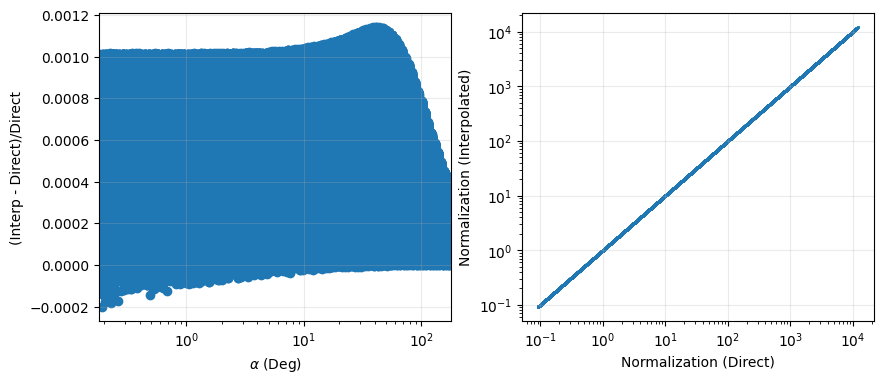

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
direct = k.norm(alpha, beta)
interp = ik.norm(alpha, beta)
ratio = (interp-direct)/direct
_ = ax1.scatter(np.rad2deg(alpha), ratio)
_ = ax2.scatter(direct, interp, s=1)

#for val in ik.points_alpha:
#    ax1.axvline(np.rad2deg(val), linewidth=1)

ax1.grid(alpha=0.25)
ax1.set_xscale('log')
#ax1.set_yscale('log')
ax1.set_xlim(np.rad2deg(alpha.min()), np.rad2deg(alpha.max()))
ax1.set_xlabel(r"$\alpha$ (Deg)")
ax1.set_ylabel("(Interp - Direct)/Direct")

#ax1.set_yscale('symlog')
#scale.SymmetricalLogScale(ax1.yaxis, linthresh=1e-4)

ax2.grid(alpha=0.25)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("Normalization (Direct)")
ax2.set_ylabel("Normalization (Interpolated)")


print(np.rad2deg(ik.points_alpha).min())
print((ik.points_alpha.nbytes+ik.points_beta.nbytes+ik.log10_grid_norms.nbytes)/1024**2)
print((3*ik.log10_grid_norms.nbytes)/1024**2)

Text(0, 0.5, 'Probability Density (1/sr)')

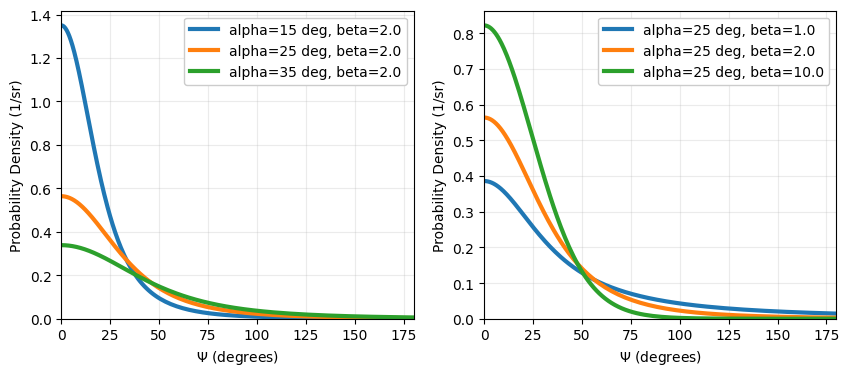

In [5]:
# Make a test plot with alpha and beta in PDFs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
x = np.logspace(-5, np.log10(np.pi), 500)
alphas = np.deg2rad([15, 25, 35])
betas = [1.0, 2.0, 10.0]

# Left plot: demo of alpha effect. Assume beta=2
for alpha in alphas:
    beta = betas[1]
    label = f"alpha={np.degrees(alpha):>2.0f} deg, beta={beta}"
    pdf = k.pdf(x, alpha, beta)
    ax1.plot(np.degrees(x), pdf, label=label,
             linewidth=3)

ax1.grid(alpha=0.25)
ax1.legend(framealpha=1)
ax1.set_xlim(0, 180)
ax1.set_ylim(ymin=0)
ax1.set_xlabel(r"$\Psi$ (degrees)")
ax1.set_ylabel(r"Probability Density (1/sr)")

# Right plot: demo of beta effect. Assume the middle alpha value.
for beta in betas:
    alpha = alphas[1]
    label = f"alpha={np.degrees(alpha):>2.0f} deg, beta={beta}"
    pdf = k.pdf(x, alpha, beta)
    ax2.plot(np.degrees(x), pdf, label=label,
             linewidth=3)

ax2.grid(alpha=0.25)
ax2.legend(framealpha=1)
ax2.set_xlim(0, 180)
ax2.set_ylim(ymin=0)
ax2.set_xlabel(r"$\Psi$ (degrees)")
ax2.set_ylabel(r"Probability Density (1/sr)")

Text(0, 0.5, 'Probability Density (1/sr)')

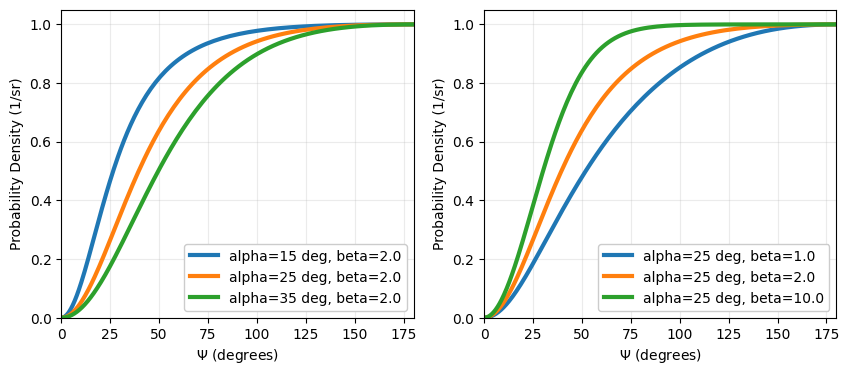

In [8]:
# Make a test plot with alpha and beta for CDFs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
x = np.logspace(-5, np.log10(np.pi), 500)
alphas = np.deg2rad([15, 25, 35])
betas = [1.0, 2.0, 10.0]

# Left plot: demo of alpha effect. Assume beta=2
for alpha in alphas:
    beta = betas[1]
    label = f"alpha={np.degrees(alpha):>2.0f} deg, beta={beta}"
    cdf = k.cdf(x, alpha, beta)
    #cdf = distribution._unnormalized_cdf(x, alpha, beta)
    ax1.plot(np.degrees(x), cdf, label=label,
             linewidth=3)

ax1.grid(alpha=0.25)
ax1.legend(framealpha=1)
ax1.set_xlim(0, 180)
ax1.set_ylim(ymin=0)
ax1.set_xlabel(r"$\Psi$ (degrees)")
ax1.set_ylabel(r"Probability Density (1/sr)")

# Right plot: demo of beta effect. Assume the middle alpha value.
for beta in betas:
    alpha = alphas[1]
    label = f"alpha={np.degrees(alpha):>2.0f} deg, beta={beta}"
    cdf = k.cdf(x, alpha, beta)
    ax2.plot(np.degrees(x), cdf, label=label,
             linewidth=3)

ax2.grid(alpha=0.25)
ax2.legend(framealpha=1)
ax2.set_xlim(0, 180)
ax2.set_ylim(ymin=0)
ax2.set_xlabel(r"$\Psi$ (degrees)")
ax2.set_ylabel(r"Probability Density (1/sr)")

Text(0, 0.5, 'Signal-subtracted Probability Density')

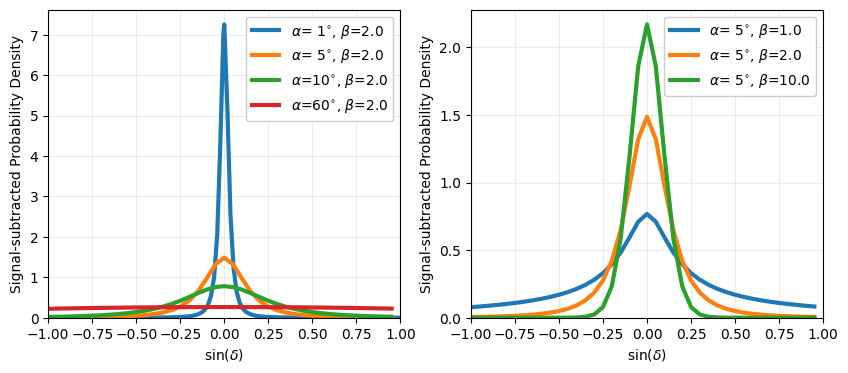

In [9]:
# Make a test plot with alpha and beta in PDFs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
dec = 0
alphas = np.deg2rad([1, 5, 10, 60])
betas = [1.0, 2.0, 10.0]

# Left plot: demo of alpha effect. Assume beta=2
for alpha in alphas:
    beta = betas[1]
    alabel = r"$\alpha$"
    blabel = r"$\beta$"
    deg = r"$^{\circ}$"
    label = f"{alabel}={np.degrees(alpha):>2.0f}{deg}, {blabel}={beta}"
    sindec, pdf = k.marginalize(dec, alpha, beta)
    ax1.plot(sindec, pdf, label=label,
             linewidth=3)

ax1.grid(alpha=0.25)
ax1.legend(loc='upper right', framealpha=1)
ax1.set_ylim(ymin=0)
ax1.set_xlim(-1, 1)
ax1.set_xlabel(r"sin($\delta$)")
ax1.set_ylabel(r"Signal-subtracted Probability Density")

# Right plot: demo of beta effect. Assume the middle alpha value.
for beta in betas:
    alpha = alphas[1]
    label = f"{alabel}={np.degrees(alpha):>2.0f}{deg}, {blabel}={beta}"
    sindec, pdf = k.marginalize(dec, alpha, beta)
    ax2.plot(sindec, pdf, label=label,
             linewidth=3)

ax2.grid(alpha=0.25)
ax2.legend(framealpha=1)
ax2.set_ylim(ymin=0)
ax2.set_xlim(-1, 1)
ax2.set_xlabel(r"sin($\delta$)")
ax2.set_ylabel(r"Signal-subtracted Probability Density")

1 100000
5 20000
10 10000
50 2000
100 1000
500 200
1000 100
5000 20
10000 10


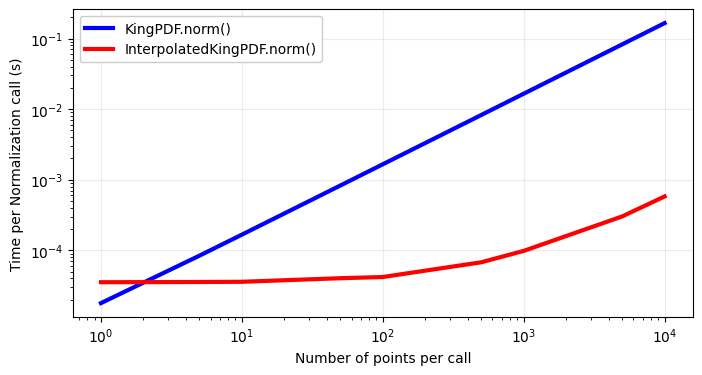

In [10]:
number = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000]
direct = []
indirect = []
for n in number:
    ntrials = int(1e5//n)
    print(n, ntrials)
    alpha = np.random.uniform(0, np.pi, n)
    beta = np.random.uniform(1.5, 3.5, n)
    direct.append( timeit(lambda: k.norm(alpha, beta), number=ntrials)/ntrials )
    indirect.append( timeit(lambda: ik.norm(alpha, beta), number=ntrials)/ntrials )

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(number, direct, linewidth=3, color='b', label='KingPDF.norm()')
ax.plot(number, indirect, linewidth=3, color='r', label='InterpolatedKingPDF.norm()')

ax.set_xlabel("Number of points per call")
ax.set_ylabel("Time per Normalization call (s)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(alpha=0.25)
ax.legend(framealpha=1)

0.1 3
0.19952623149688797 3
0.39810717055349726 3
0.7943282347242814 3
1.5848931924611134 3
3.1622776601683795 3
6.309573444801931 3
12.589254117941675 3
25.118864315095795 3
50.118723362727195 3
100.0 3


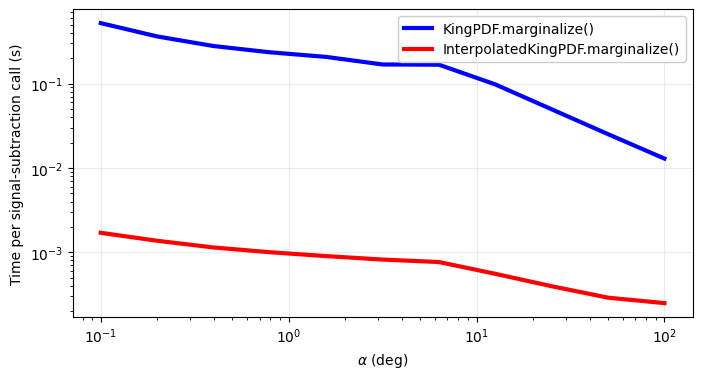

In [32]:
alphas = np.deg2rad(np.logspace(-1, 2, 11))
beta = 3
direct = []
indirect = []
for alpha in alphas:
    ntrials = 10
    print(np.rad2deg(alpha), beta)
    direct.append( timeit(lambda: k.marginalize(0, alpha, beta), number=ntrials)/ntrials )
    indirect.append( timeit(lambda: ik.marginalize(0, alpha, beta), number=ntrials)/ntrials )

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(np.rad2deg(alphas), direct, linewidth=3, color='b', label='KingPDF.marginalize()')
ax.plot(np.rad2deg(alphas), indirect, linewidth=3, color='r', label='InterpolatedKingPDF.marginalize()')

ax.set_xlabel(r"$\alpha$ (deg)")
ax.set_ylabel("Time per signal-subtraction call (s)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(alpha=0.25)
ax.legend(framealpha=1)

In [33]:
pi0 = np.load("../Fermi-LAT_pi0_map.npy")
tskp = TemplateSmearedKingPDF(pi0, eval_decs=[0], eval_ras=np.deg2rad([0]), 
                             )#angular_cutoff=np.deg2rad(10))

smeared_map = tskp.convolve_map(np.deg2rad(20), 3.0)
smeared_point = tskp.convolve_at_grid_point(np.deg2rad(20), 3.0)

In [34]:
%timeit tskp.get_king_b_l(np.deg2rad(20), 3.0)
%timeit tskp.convolve_map(np.deg2rad(20), 3.0)
%timeit tskp.convolve_at_grid_point(np.deg2rad(20), 3.0)

201 μs ± 1.02 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.61 ms ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
406 μs ± 1.52 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


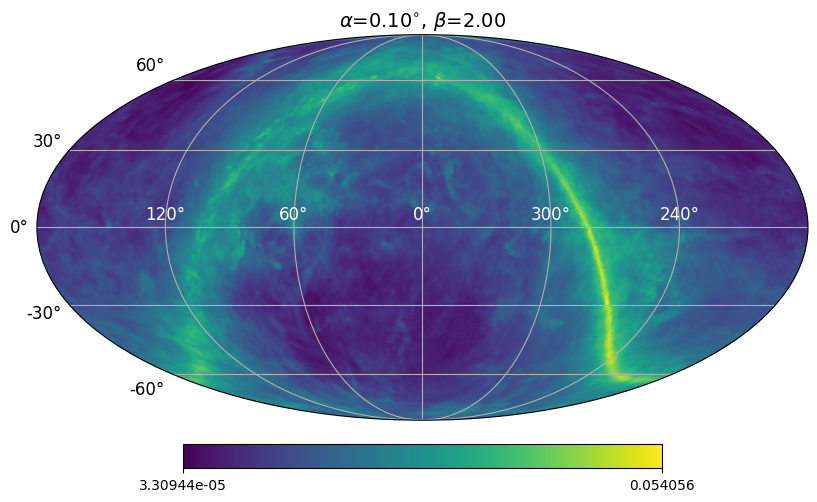

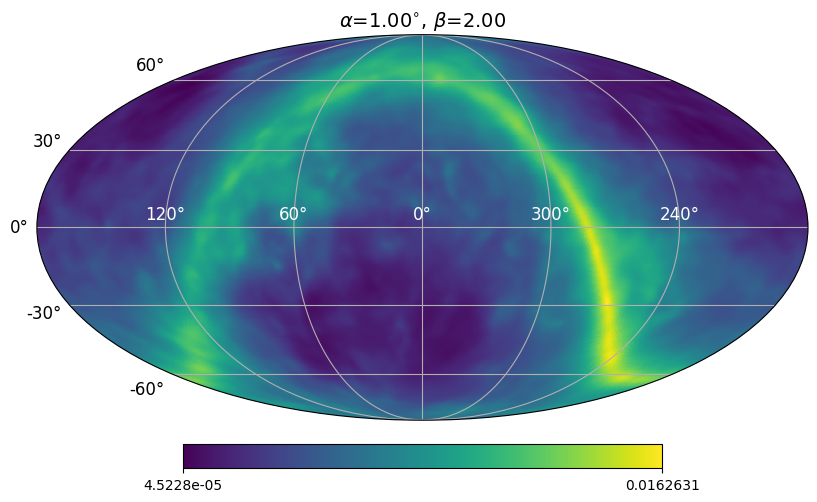

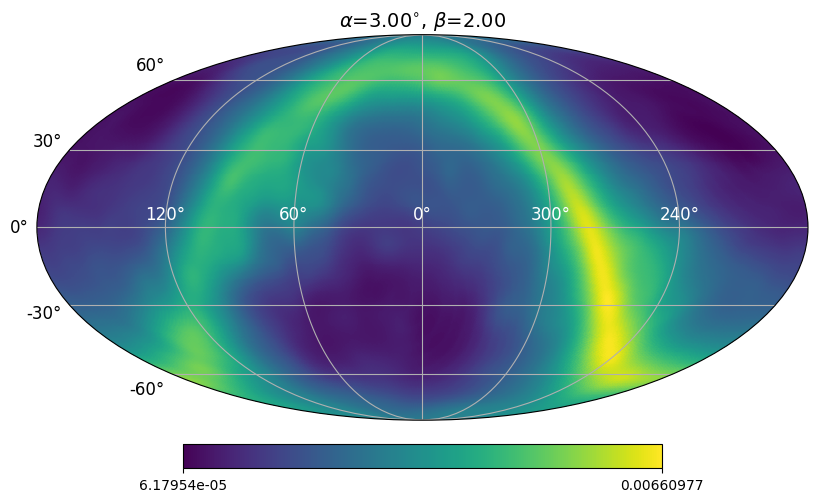

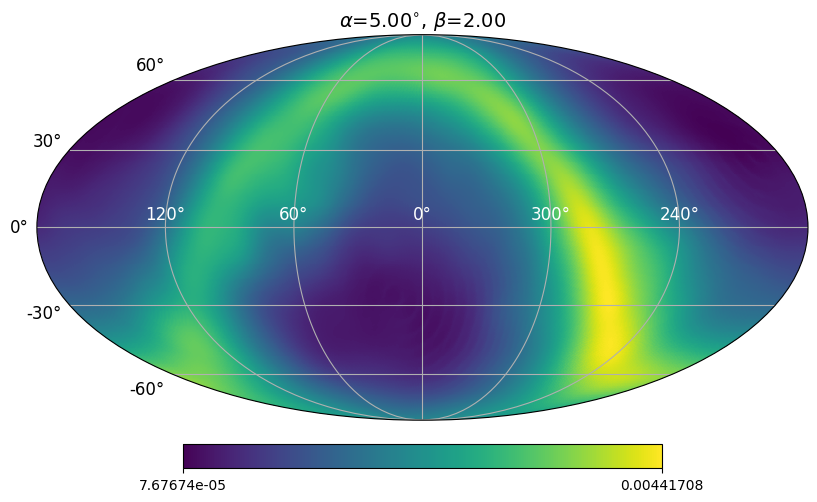

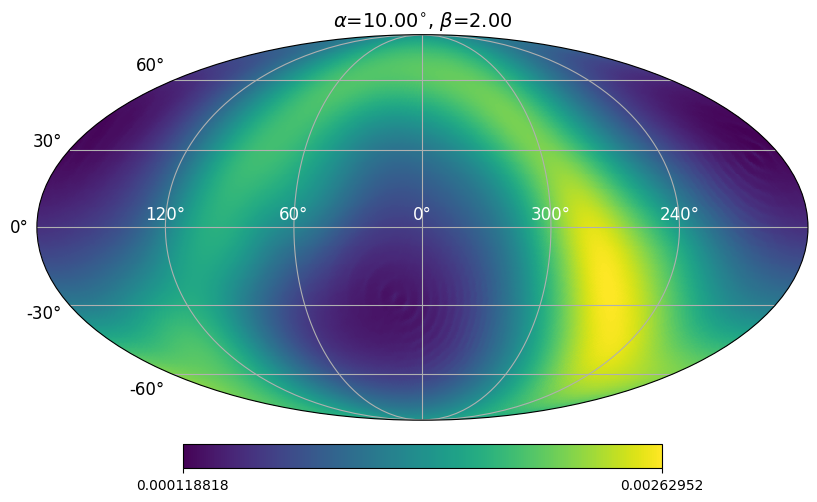

In [88]:
import healpy as hp
alphas = np.deg2rad([0.1, 1, 3, 5, 10])
beta = 2

for alpha in alphas:
    convolved_map = tskp.convolve_map(alpha, beta)
    hp.newvisufunc.projview(convolved_map, 
                            norm='log', 
                            graticule=True, 
                            graticule_labels=True,
                            title=r"$\alpha$=" + f"{np.rad2deg(alpha):4.2f}" + r"$^{\circ}$, $\beta$=" + f"{beta:4.2f}",
                            xtick_label_color='w',)

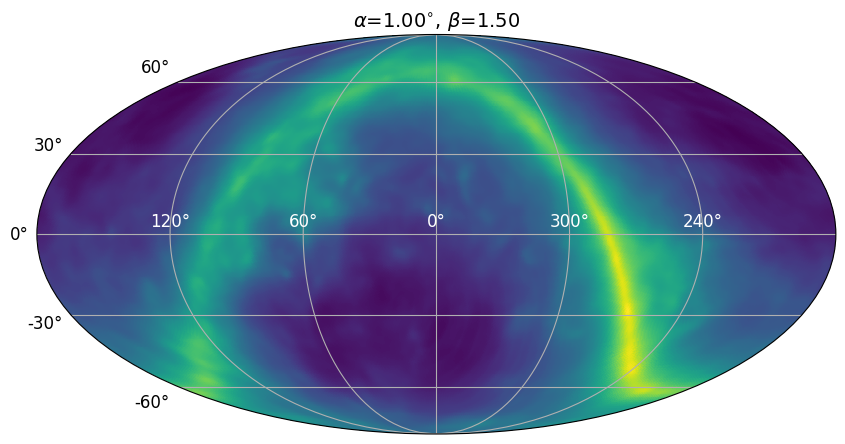

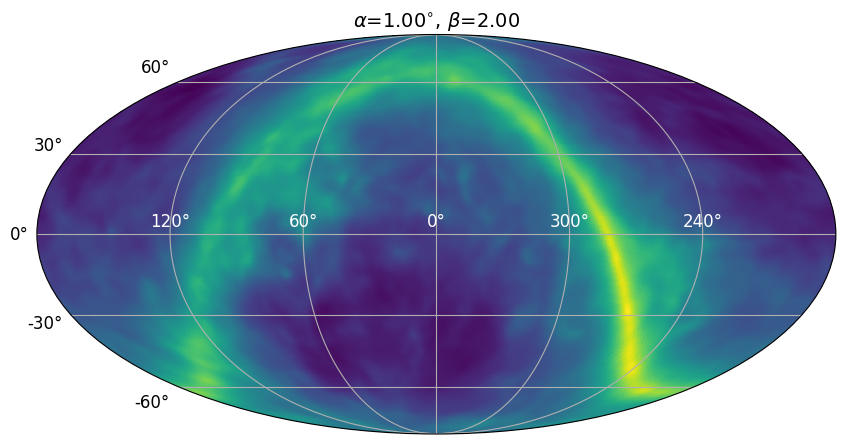

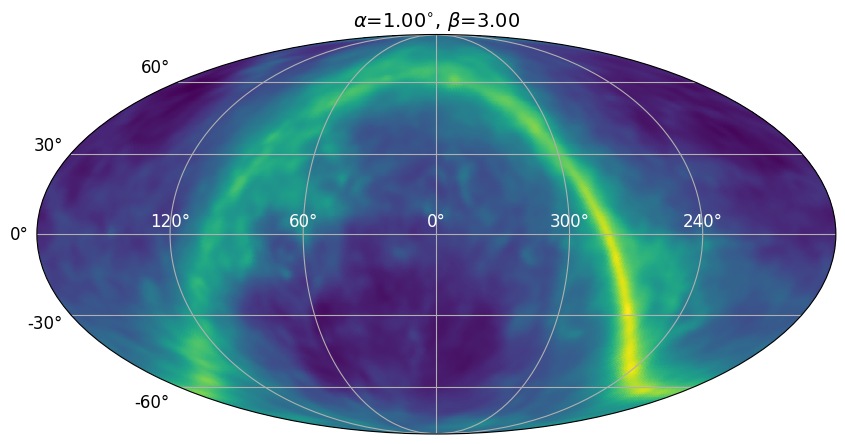

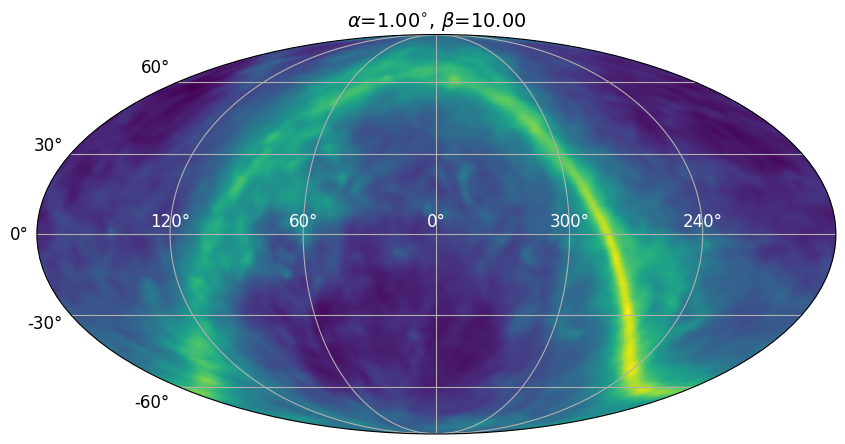

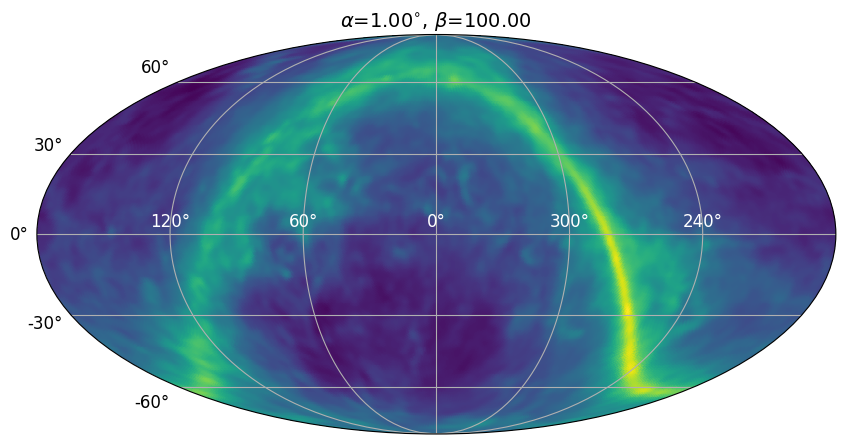

In [87]:
import healpy as hp
alpha = np.deg2rad(1)
betas = [1.5, 2, 3, 10, 100]

for beta in betas:
    convolved_map = tskp.convolve_map(alpha, beta)
    hp.newvisufunc.projview(convolved_map, 
                            norm='log', 
                            graticule=True, 
                            graticule_labels=True,
                            cbar = False,
                            title=r"$\alpha$=" + f"{np.rad2deg(alpha):4.2f}" + r"$^{\circ}$, $\beta$=" + f"{beta:4.2f}",
                            xtick_label_color='w',)

In [ ]:
return_only_data